# EXERCISE 1 : GRAPE using Optim.jl

In [13]:
import Pkg
#Pkg.rm("HarmonicSolvers")
#Pkg.gc()
Pkg.develop(path="/Users/jettajb1/Work/DiffEQ/HarmonicSolvers/")

   Resolving package versions...
     Project No packages added to or removed from `~/Work/Project.toml`
    Manifest No packages added to or removed from `~/Work/Manifest.toml`


In [14]:
using DifferentialEquations
using Optim
using Pkg
using Revise
using HarmonicSolvers
using LinearAlgebra
using Plots

In [15]:
N = 20
t = 0.5

struct QuantumSystem{M,V}
    H_drift::M
    H_drives::V
end

function schrodinger!(dψ, ψ, p,t)
    #find the current step and update dpsi
    # each energy eigensatet evolve in time by picking up a phase e^Et/h
    #find which step(page) use that to find the u(t)(amplitude _> force u need apply according to the page)
    
    sys, u_values, dt = p
    idx = min((floor(Int,t/dt) + 1), length(u_values)) #tiem step doesnt excee array length
    u_t = u_values[idx]
    coeff = -0.5im *u_t 
    mul!(dψ, sys.H_drives,ψ,coeff,0)


end

schrodinger! (generic function with 1 method)

In [16]:
sys_matrices = QuantumSystem( [0.0 0.0; 0.0 0.0], [0.0 1.0; 1.0 0.0])
u0_state = [1.0 + 0.0im, 0.0 + 0.0im]
ψ_target = [0.0 + 0.0im, 1.0 + 0.0im]
t_span = (0.0, N*t)
dt_step = 0.5
rk4_solver = RungeKutta4()


RungeKutta4()

In [17]:

function objective(controls)
    params = ( 
    sys = sys_matrices,
    controls = controls,
    dt = dt_step
    )
    #run through and ask schrdingger along the way for the trajectory of the state and input into runge kutta to push the satte to the end then comapre that satate with your target state 
    prob = MyODEProblem(schrodinger!, u0_state, t_span,params)
    result = integrate(prob,rk4_solver,dt=dt_step)
    ψ_final = result.u[end]
    fiedelity = abs2(dot(ψ_target, ψ_final)) 
    return 1.0-fiedelity #how succesfully ur control manipulates ur qubit
end

objective (generic function with 1 method)

In [18]:
const X = [0.0 1.0; 1.0 0.0]
const Z = [1.0 0.0; 0.0 -1.0]
const ψ_Y = 1sqrt(2) .* [1.0 + 0.0im; 0.0 + 1.0im]


2-element Vector{ComplexF64}:
 1.4142135623730951 + 0.0im
                0.0 + 1.4142135623730951im

In [19]:
#qubits roatate on their own if your control pulse doesnt actively account for the backgorund rotation your state will go off course

function schrodinger_drift!(dψ,ψ,p,t)
    H_drift, H_drives, u_vector, dt = p

    idx = floor(Int,t/dt)+1
    idx = min((floor(Int,t/dt)+1),length(u_vector))
    u_t = u_vector[idx]

    fill!(dψ,0.0)
    mul!(dψ,H_drift,ψ,-1.0im,0.0)
    mul!(dψ,H_drives,ψ,-1.0im*u_t,1.0)
end




schrodinger_drift! (generic function with 1 method)

In [20]:
function cosine_basis(n_modes::Int, N::Int)
    τ = (0:N-1) ./ N
    # Creates a list of vectors, one vector for each mode j
    return [cos.(π * j .* (τ .- 0.5)) for j in 0:(n_modes - 1)]
end


cosine_basis (generic function with 1 method)

In [21]:
function expand_control(coefficients, basis)
    return sum(c.*b for (c,b) in zip(coefficients,basis))
end

expand_control (generic function with 1 method)

In [22]:
n_modes = 4
g_basis = cosine_basis(n_modes,N)
function objective_v2(coefficients::Vector{Float64}) #dimensionality reduction 
    flat = vec(coefficients)
    controls = expand_control(flat,g_basis)

    H_drift = 0.1* [1.0 0.0;0.0 -1.0]
    H_drives = [0.0 1.0; 1.0 0.0]
    dt_step = 0.5

    sys = QuantumSystem(H_drift,H_drives)
    params = (sys, controls, dt_step)

    prob = MyODEProblem(schrodinger!,u0_state, t_span,params)
    result = integrate(prob, rk4_solver; dt=dt_step)
    ψ_final = result.u[end]
    fidelity = abs2(dot(ψ_Y, ψ_final))

    return 1.0-fidelity
end



objective_v2 (generic function with 1 method)

Objective 1 Final Infidelity
[7.066953535084095, 13.84506863635571, 27.368013090264476, -5.9648635591572985, -20.0099725141272, -0.47730589528251144, -1.2726864908398978, 15.44332765708945, -0.7988953515866344, -82.05327291387799, 102.91608236693153, -6.268751795318586, -1.612614676386622, -0.8579011977128039, -34.62020613981808, 9.619598399935182, 7.0076684667884095, -2.7725037994086894, -5.454275401504834, 6.739760981191774]
Objective 2 Final Infidelity
[-6.029907101178912, 7.130679850827195, -3.2378537793455284, -0.366832234795047]


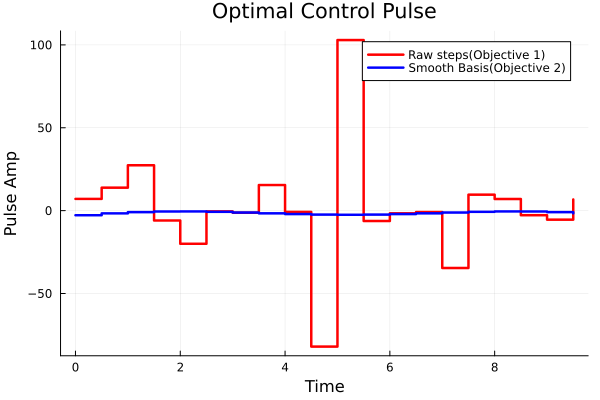

In [23]:
init_control = rand(20)
result_v1 = optimize(objective, init_control)
best_control_v1 = Optim.minimizer(result_v1)

println("Objective 1 Final Infidelity")
println(best_control_v1)
init_coeff = randn(4)
result_v2 = optimize(objective_v2, init_coeff)
best_coeff = Optim.minimizer(result_v2)


println("Objective 2 Final Infidelity")
println(best_coeff)
best_controls_v2 =expand_control(best_coeff,g_basis)

time_axis = (0:19) .* dt_step
p = plot(xlabel="Time",ylabel="Pulse Amp",title="Optimal Control Pulse",lw=2)
plot!(p,time_axis,best_control_v1,label="Raw steps(Objective 1)",color=:red,linetype=:steppost,lw=2.5)
plot!(p,time_axis,best_controls_v2,label="Smooth Basis(Objective 2)",color=:blue,linetype=:steppost,lw=2.5)
display(p)